--- Hardware Parameters (Q16) ---
COEFF_A (High Split @ 2500Hz):  18290
COEFF_B (Mid Split @ 315Hz):    2647
COEFF_C (Low Split @ 16.5Hz):    141
---------------------------------


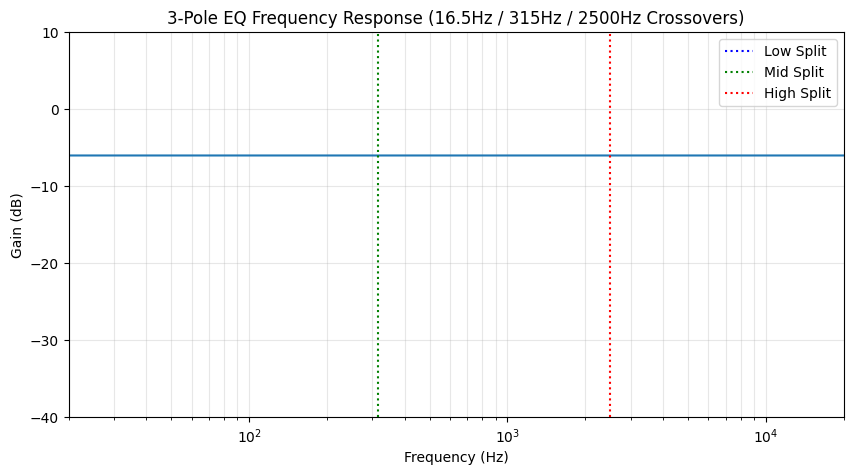

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def get_crossover_coeff(fc, fs, bit_depth=16):
    """
    Calculates the hardware coefficient for a one-pole leaky integrator.
    coeff = 1 - exp(-2 * pi * fc / fs)
    """
    # Standard formula for mapping analog cutoff to digital one-pole coefficient
    coeff_float = 1.0 - np.exp(-2.0 * np.pi * fc / fs)
    
    # Scale to fixed-point integer
    scaling_factor = 2**bit_depth
    return int(coeff_float * scaling_factor)

def model_dynamic_eq(low_f, mid_f, high_f, low_g_raw, mid_g_raw, high_g_raw, fs=48000):

    # Calculate the coefficients for the cutoffs
    val_a = get_crossover_coeff(high_f, fs)
    val_b = get_crossover_coeff(mid_f, fs)
    val_c = get_crossover_coeff(low_f, fs)

    print(f"--- Hardware Parameters (Q16) ---")
    print(f"COEFF_A (High Split @ {high_f}Hz):  {val_a}")
    print(f"COEFF_B (Mid Split @ {mid_f}Hz):    {val_b}")
    print(f"COEFF_C (Low Split @ {low_f}Hz):    {val_c}")
    print(f"---------------------------------")

    # Map gains: 128 = Unity (1.0)
    g_low  = (low_g_raw * 128) / 32768.0
    g_mid  = (mid_g_raw * 128) / 32768.0
    g_high = (high_g_raw * 128) / 32768.0

    # Frequency analysis
    w, h = signal.freqz([1], [1], worN=8000, fs=fs)
    z = np.exp(1j * 2 * np.pi * w / fs)

    # One-Pole Transfer Function: H(z) = alpha / (z - (1 - alpha))
    def get_h(val):
        alpha = val / 65536.0
        return alpha / (z - (1 - alpha))

    lpf_a = get_h(val_a)
    lpf_b = get_h(val_b)
    lpf_c = get_h(val_c)

    # Reconstruct the bands exactly like the Verilog logic
    # - band_high[n]    = audio_in[n] - filter_a[n]
    # - band_mid[n]     = filter_a[n] - filter_b[n]
    # - band_low[n]     = filter_b[n] - filter_c[n]
    # - band_lowpass[n] = filter_c[n]
    h_high    = 1.0 - lpf_a
    h_mid     = lpf_a - lpf_b
    h_low     = lpf_b - lpf_c
    h_lowpass = lpf_c

    # Summing result (note: lowpass uses low gain)
    total_h = (h_high * g_high) + (h_mid * g_mid) + (h_low * g_low) + (h_lowpass * g_low)
    return w, total_h

# --- SETTINGS ---
FS = 48000
LOW_CUTOFF = 16.5    # Lowest frequency split
MID_CUTOFF = 315    # Mid-low to mid-high split
HIGH_CUTOFF = 2500  # High frequency split

# --- MAIN ---

# Run model: 
freqs, response = model_dynamic_eq(LOW_CUTOFF, MID_CUTOFF, HIGH_CUTOFF, 128, 128, 128, FS)

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.semilogx(freqs, 20 * np.log10(np.abs(response) + 1e-6))
plt.axvline(LOW_CUTOFF, color='blue', linestyle=':', label='Low Split')
plt.axvline(MID_CUTOFF, color='green', linestyle=':', label='Mid Split')
plt.axvline(HIGH_CUTOFF, color='red', linestyle=':', label='High Split')
plt.title(f'3-Pole EQ Frequency Response ({LOW_CUTOFF}Hz / {MID_CUTOFF}Hz / {HIGH_CUTOFF}Hz Crossovers)')
plt.ylabel('Gain (dB)')
plt.xlabel('Frequency (Hz)')
plt.ylim(-40, 10)
plt.xlim(20, 20000)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()